#Import the Libraries

In [18]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

#Convert the dataset into a dataframe

In [2]:
data = {
    "machine_runtime_hours": [
        101.2, 96.8, 122.5, 87.9, 135.1,
        108.6, 116.2, 82.7, 128.3, 93.5,
        140.4, 91.6, 119.8, 104.7, 132.1
    ],

    "energy_consumption_kwh": [
        507.1, 485.6, 611.8, 438.2, 674.5,
        548.7, 579.9, 421.5, 646.3, 469.8,
        701.2, 432.7, 594.1, 525.4, 665.8
    ],

    "labor_hours": [
        209.8, 191.3, 251.7, 173.5, 279.6,
        223.9, 235.2, 164.8, 261.1, 183.6,
        291.5, 171.9, 244.3, 216.5, 273.7
    ],

    "raw_material_cost": [
        12380.5, 11895.2, 14820.6, 11025.8, 16410.7,
        13240.3, 13910.1, 10540.9, 15670.4, 11450.7,
        17280.8, 10890.5, 14460.2, 12810.4, 16090.3
    ],

    "downtime_minutes": [
        19.5, 24.7, 14.2, 31.6, 10.8,
        20.1, 17.2, 35.9, 12.6, 27.3,
        9.4, 33.1, 15.5, 22.8, 11.7
    ],

    "ambient_temperature": [
        70.8, 69.4, 73.6, 68.2, 74.9,
        71.1, 72.7, 67.5, 74.1, 69.0,
        75.6, 68.7, 73.2, 70.5, 74.4
    ],

    "shift_supervisor_score": [
        6.9, 7.0, 7.6, 6.1, 8.0,
        7.2, 7.4, 5.8, 7.8, 6.4,
        8.3, 6.0, 7.5, 6.8, 7.9
    ],

    "sensor_variation_index": [
        0.42, -1.18, 0.91, -0.54, 1.73,
        -0.62, 0.37, -1.41, 1.08, -0.27,
        2.11, -0.83, 0.58, -0.11, 1.49
    ],

    "production_output": [
        40520.6, 37210.4, 48640.2, 33490.5, 54480.1,
        43410.8, 45820.7, 31150.9, 51760.3, 35840.1,
        57120.4, 32690.8, 47450.6, 42030.7, 53280.2
    ]
}

In [3]:
df = pd.DataFrame(data)

In [4]:
df

,machine_runtime_hours,energy_consumption_kwh,labor_hours,raw_material_cost,downtime_minutes,ambient_temperature,shift_supervisor_score,sensor_variation_index,production_output
0,101.2,507.1,209.8,12380.5,19.5,70.8,6.9,0.42,40520.6
1,96.8,485.6,191.3,11895.2,24.7,69.4,7.0,-1.18,37210.4
2,122.5,611.8,251.7,14820.6,14.2,73.6,7.6,0.91,48640.2
3,87.9,438.2,173.5,11025.8,31.6,68.2,6.1,-0.54,33490.5
4,135.1,674.5,279.6,16410.7,10.8,74.9,8.0,1.73,54480.1
5,108.6,548.7,223.9,13240.3,20.1,71.1,7.2,-0.62,43410.8
6,116.2,579.9,235.2,13910.1,17.2,72.7,7.4,0.37,45820.7
7,82.7,421.5,164.8,10540.9,35.9,67.5,5.8,-1.41,31150.9
8,128.3,646.3,261.1,15670.4,12.6,74.1,7.8,1.08,51760.3
9,93.5,469.8,183.6,11450.7,27.3,69.0,6.4,-0.27,35840.1


#Exploratory Data Analysis

<Axes: xlabel='machine_runtime_hours', ylabel='production_output'>

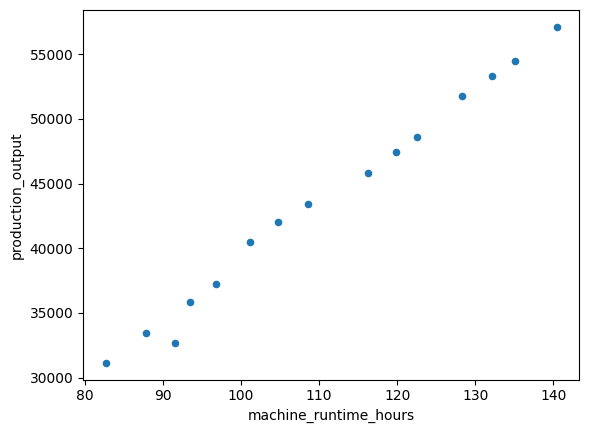

In [5]:
df.plot.scatter(x='machine_runtime_hours', y='production_output')

<Axes: xlabel='energy_consumption_kwh', ylabel='production_output'>

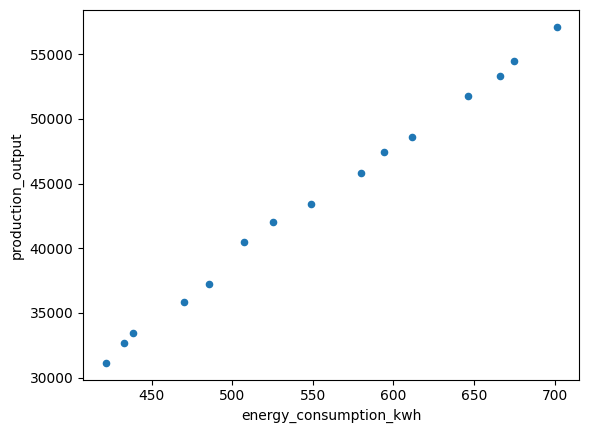

In [6]:
df.plot.scatter(x='energy_consumption_kwh', y='production_output')

<Axes: xlabel='labor_hours', ylabel='production_output'>

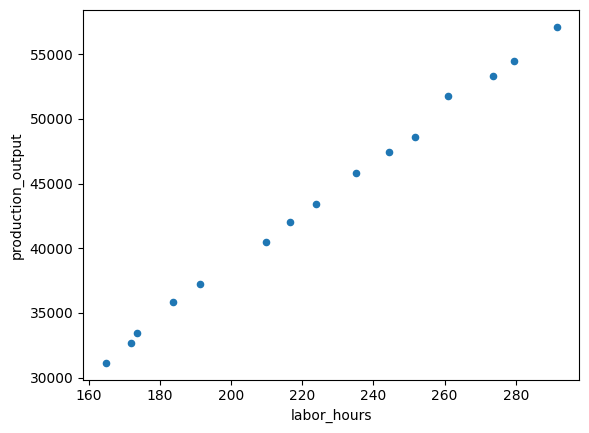

In [7]:
df.plot.scatter(x='labor_hours', y='production_output')

<Axes: xlabel='raw_material_cost', ylabel='production_output'>

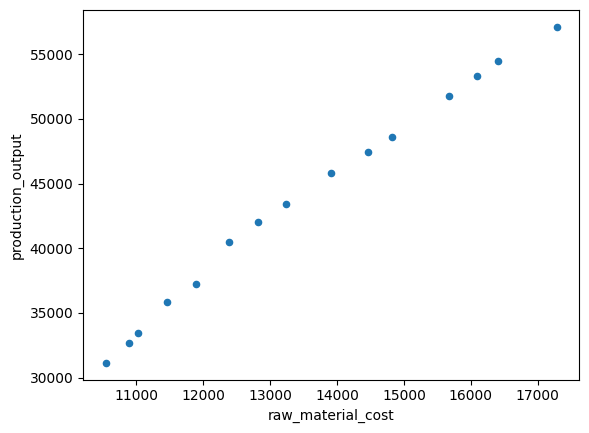

In [8]:
df.plot.scatter(x='raw_material_cost', y='production_output')

<Axes: xlabel='downtime_minutes', ylabel='production_output'>

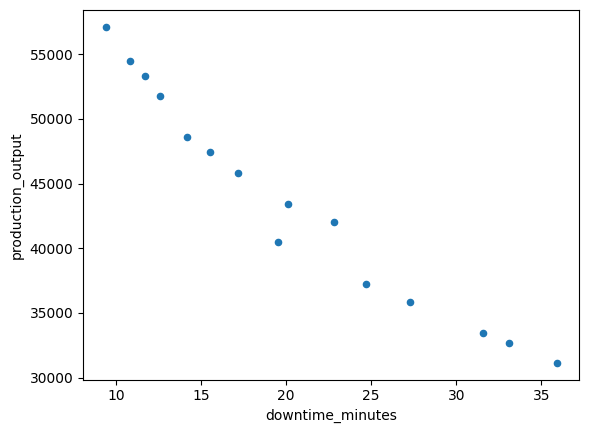

In [9]:
df.plot.scatter(x='downtime_minutes', y='production_output')

<Axes: xlabel='ambient_temperature', ylabel='production_output'>

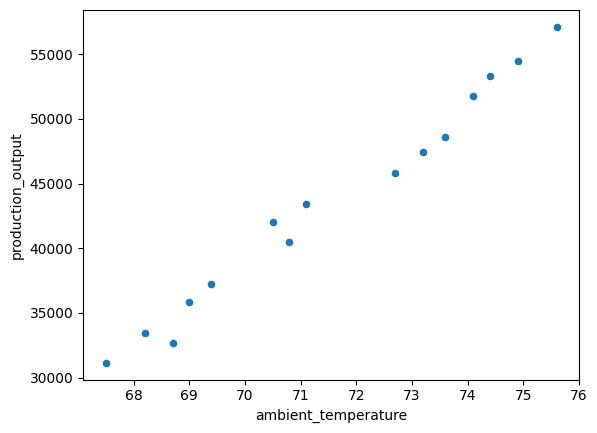

In [10]:
df.plot.scatter(x='ambient_temperature', y='production_output')

<Axes: xlabel='shift_supervisor_score', ylabel='production_output'>

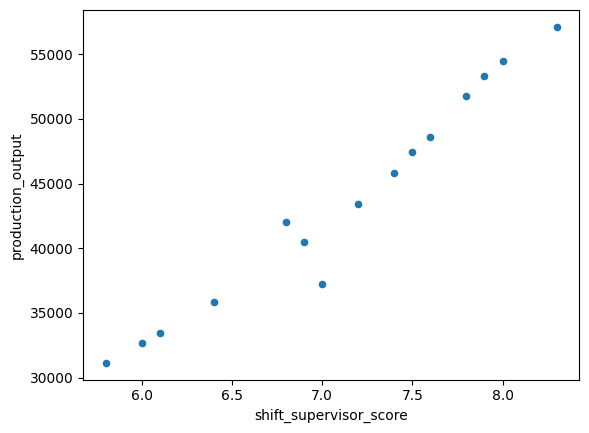

In [11]:
df.plot.scatter(x='shift_supervisor_score', y='production_output')

<Axes: xlabel='sensor_variation_index', ylabel='production_output'>

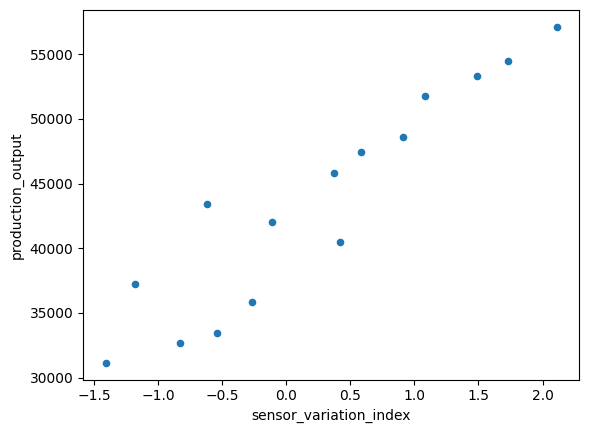

In [12]:
df.plot.scatter(x='sensor_variation_index', y='production_output')

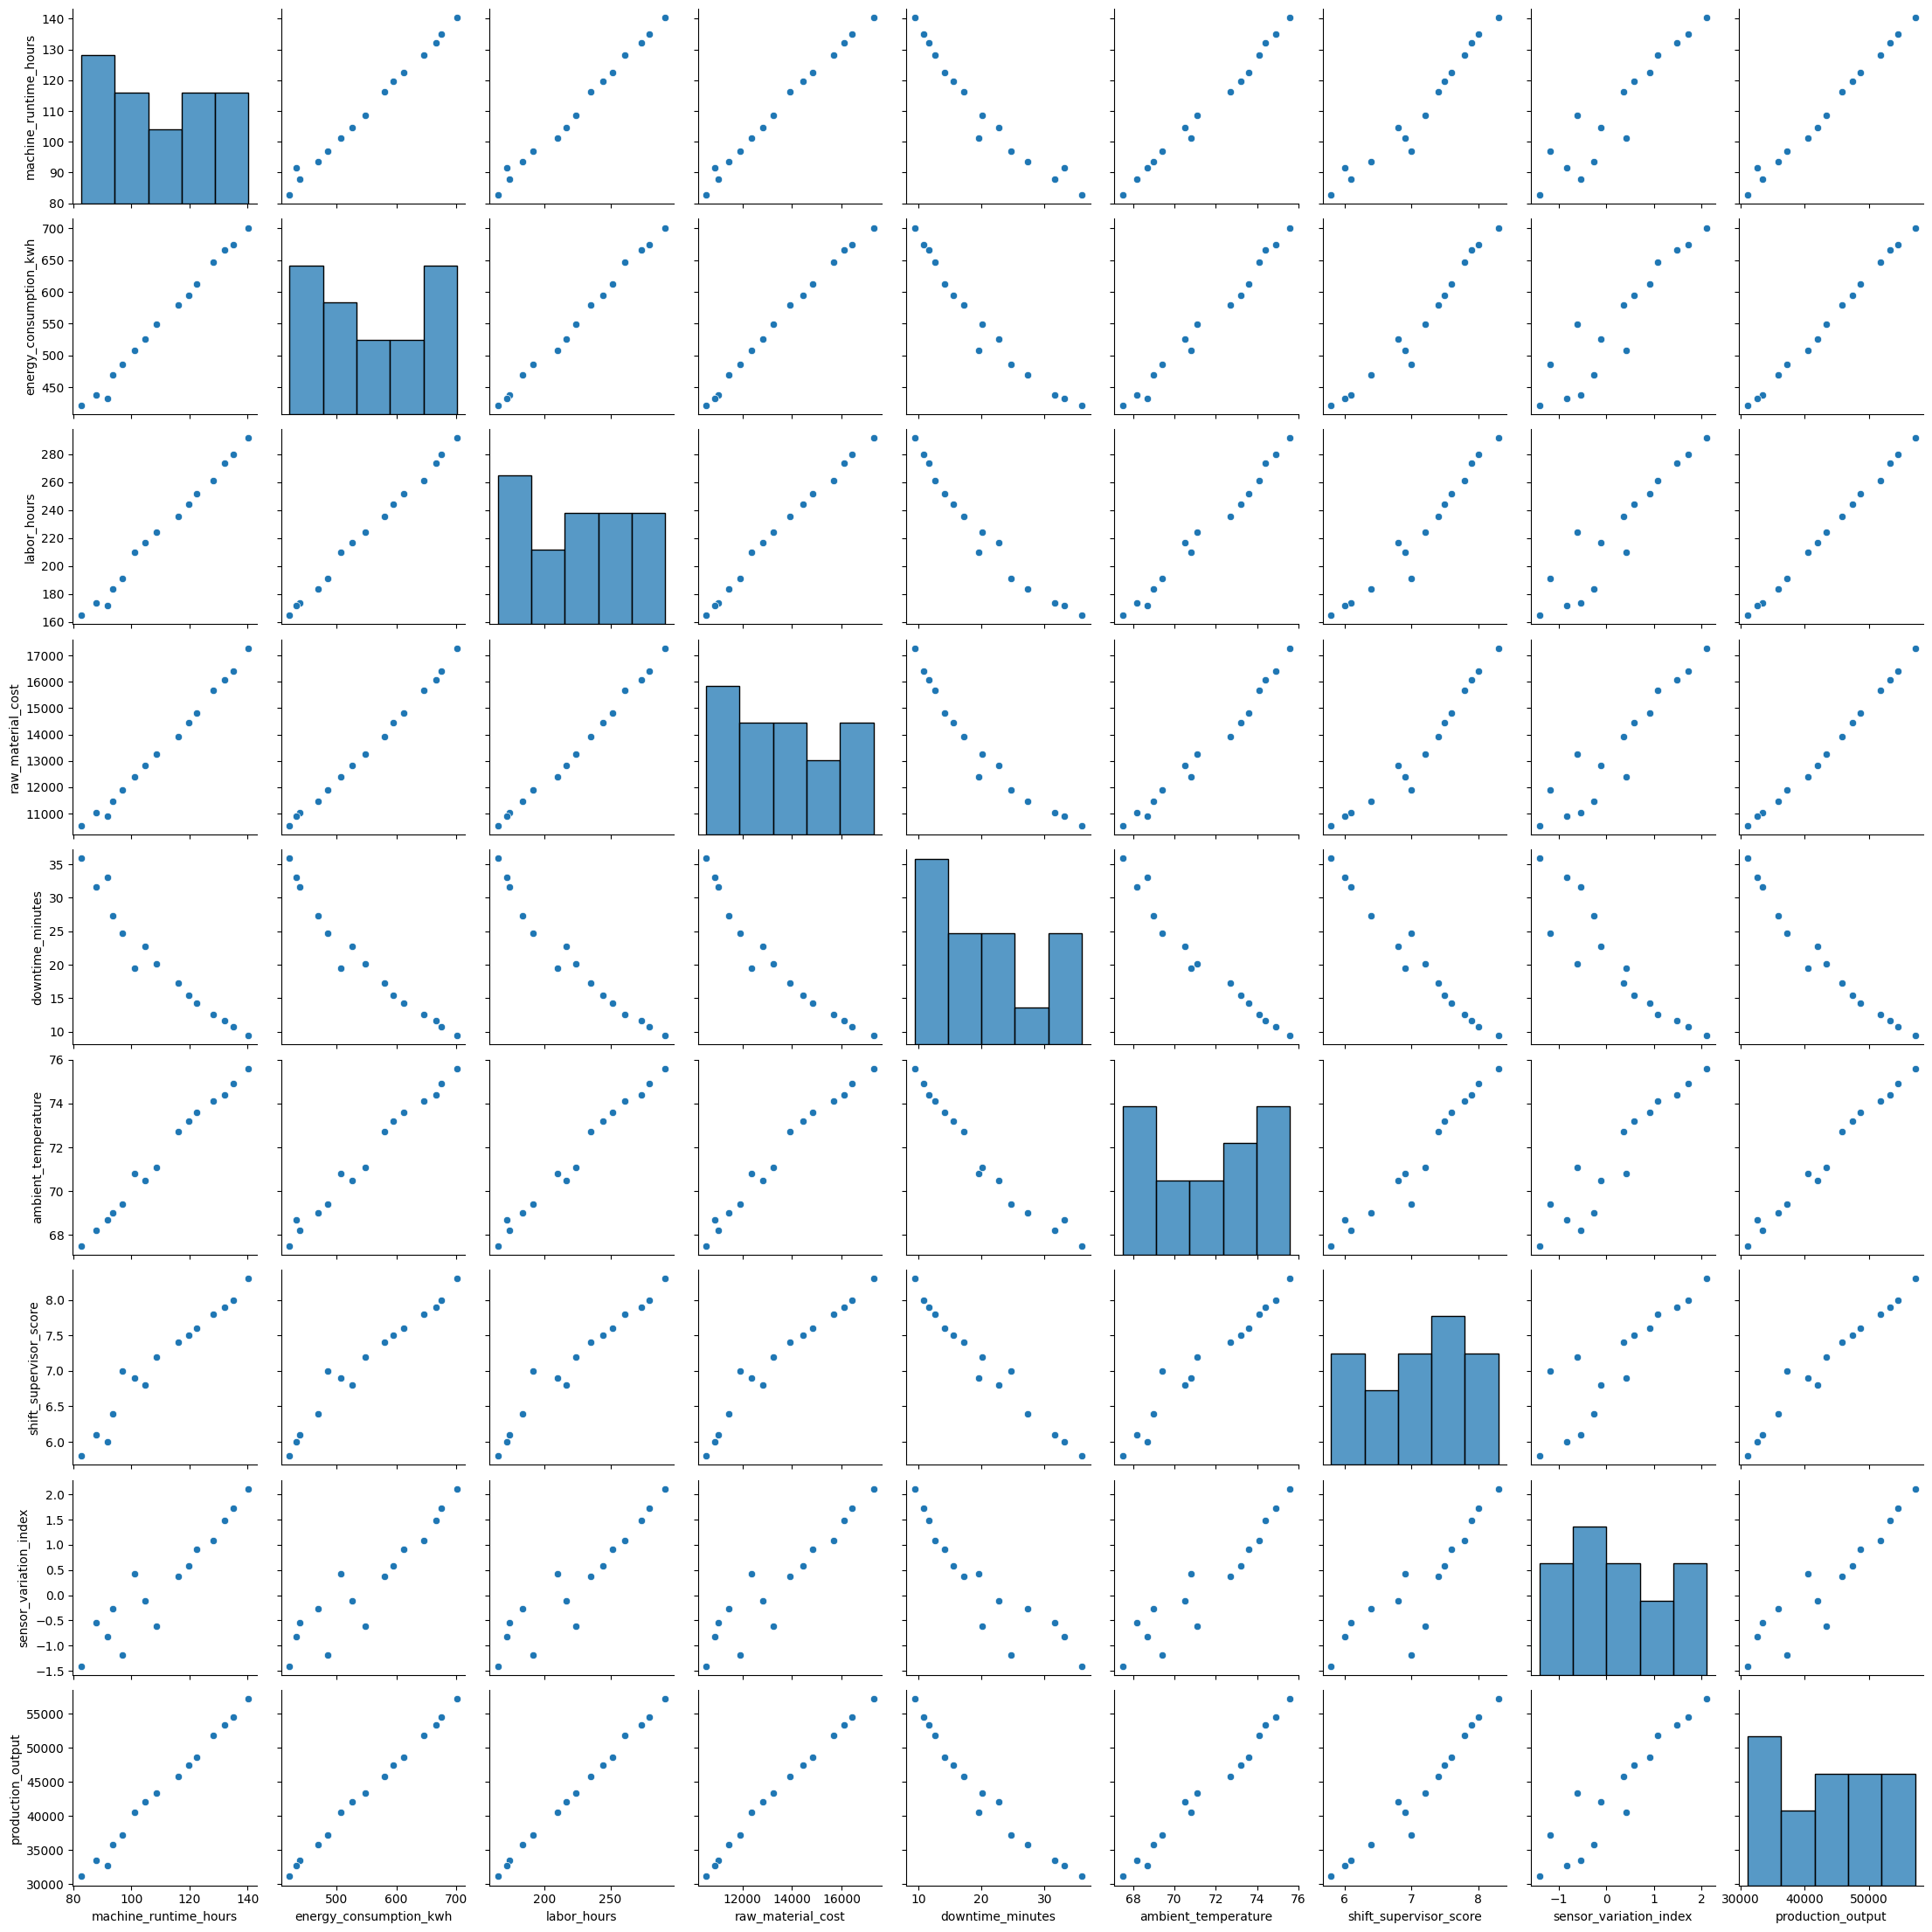

In [13]:
sns.pairplot(df)

#Set the Features and Target

In [14]:
X = df.drop('production_output', axis = 1)

In [15]:
y = df['production_output']

#Conduct the Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [19]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(max_iter=10000))
])

#Define the Param grid

In [20]:
param_grid = {'ridge__alpha': [1.0, 1.5, 2.0, 2.5, 3.0]}

#Perform Grid Search

In [21]:
grid = GridSearchCV(pipeline,param_grid,cv=3,refit=True,verbose=2)

In [22]:
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
test_preds = best_model.predict(X_test)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END ...................................ridge__alpha=1.0; total time=   0.0s
[CV] END ...................................ridge__alpha=1.0; total time=   0.0s
[CV] END ...................................ridge__alpha=1.0; total time=   0.0s
[CV] END ...................................ridge__alpha=1.5; total time=   0.0s
[CV] END ...................................ridge__alpha=1.5; total time=   0.0s
[CV] END ...................................ridge__alpha=1.5; total time=   0.0s
[CV] END ...................................ridge__alpha=2.0; total time=   0.0s
[CV] END ...................................ridge__alpha=2.0; total time=   0.0s
[CV] END ...................................ridge__alpha=2.0; total time=   0.0s
[CV] END ...................................ridge__alpha=2.5; total time=   0.0s
[CV] END ...................................ridge__alpha=2.5; total time=   0.0s
[CV] END ...................................ridge

#Find the best parameters and evaluate performance

In [23]:
print("Best Parameters:", grid.best_params_)
print("R2:", r2_score(y_test, test_preds))

Best Parameters: {'ridge__alpha': 2.0}
R2: 0.917672935058113


In [24]:
best_model.named_steps['ridge'].coef_

array([1031.22136366, 1089.02340526, 1142.17165283, 1078.29868562,
       -921.27861601,  896.99608713,  853.84571333,  867.53845048])

In [25]:
best_model.named_steps['ridge'].intercept_

np.float64(45487.149999999994)

In [26]:
pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.named_steps['ridge'].coef_
})

,Feature,Coefficient
0,machine_runtime_hours,1031.221364
1,energy_consumption_kwh,1089.023405
2,labor_hours,1142.171653
3,raw_material_cost,1078.298686
4,downtime_minutes,-921.278616
5,ambient_temperature,896.996087
6,shift_supervisor_score,853.845713
7,sensor_variation_index,867.538450
